# Bitcoin Sentiment vs Trader Performance Analysis
**Objective:** Explore how market sentiment (Fear/Greed) relates to trader behavior and performance on Hyperliquid.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('tab10')

# ── Load data ──────────────────────────────────────────────────────────────
df_fg  = pd.read_csv('fear_greed_index.csv')
df_raw = pd.read_csv('historical_data.csv')

# ── Date alignment ─────────────────────────────────────────────────────────
df_raw['date'] = pd.to_datetime(df_raw['Timestamp IST'], dayfirst=True).dt.strftime('%Y-%m-%d')
df_fg['date']  = pd.to_datetime(df_fg['date']).dt.strftime('%Y-%m-%d')

# ── Merge ──────────────────────────────────────────────────────────────────
df = pd.merge(df_raw, df_fg[['date', 'value', 'classification']], on='date', how='inner')

# ── Sentiment ordering for charts ─────────────────────────────────────────
SENTIMENT_ORDER = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
SENTIMENT_COLORS = {
    'Extreme Fear' : '#d32f2f',
    'Fear'         : '#ef6c00',
    'Neutral'      : '#9e9e9e',
    'Greed'        : '#388e3c',
    'Extreme Greed': '#1b5e20'
}

print(f'Merged rows : {len(df):,}')
print(f'Date range  : {df.date.min()} → {df.date.max()}')
print(f'Unique traders: {df.Account.nunique()}')
print()
print(df['classification'].value_counts())

Merged rows : 211,218
Date range  : 2023-05-01 → 2025-05-01
Unique traders: 32

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


## 1. Sentiment Distribution Over Time

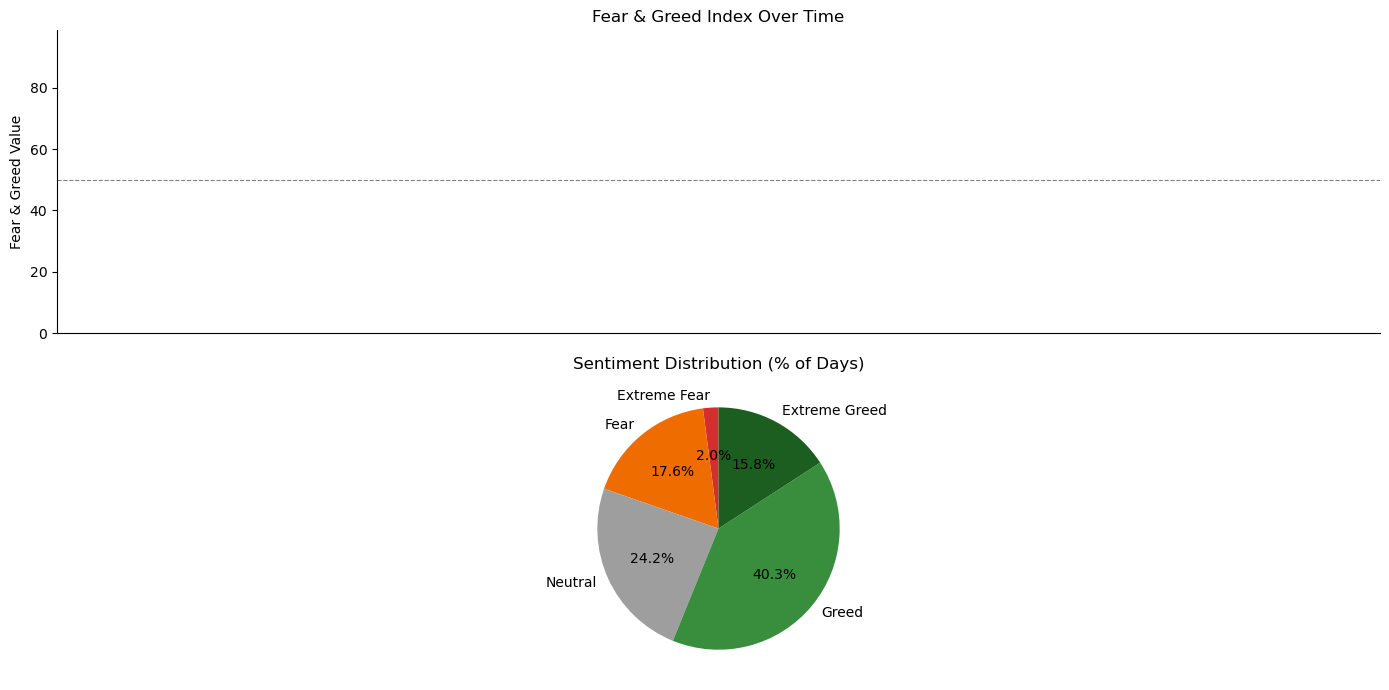

In [16]:
daily_fg = df_fg[df_fg['date'] >= df['date'].min()].copy()
daily_fg['date'] = pd.to_datetime(daily_fg['date'])

color_map = [SENTIMENT_COLORS.get(c, 'gray') for c in daily_fg['classification']]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].bar(daily_fg['date'], daily_fg['value'], color=color_map, width=1)
axes[0].axhline(50, color='black', linestyle='--', lw=0.8, alpha=0.5)
axes[0].set_ylabel('Fear & Greed Value')
axes[0].set_title('Fear & Greed Index Over Time')

dist = daily_fg['classification'].value_counts()[SENTIMENT_ORDER]
axes[1].pie(
    dist, labels=SENTIMENT_ORDER,
    colors=[SENTIMENT_COLORS[s] for s in SENTIMENT_ORDER],
    autopct='%1.1f%%', startangle=90
)
axes[1].set_title('Sentiment Distribution (% of Days)')

plt.tight_layout()
plt.savefig('01_sentiment_distribution.png', dpi=150)
plt.show()

## 2. Average Daily PnL by Sentiment

                Mean PnL  Median PnL   Total PnL  Trade Count
classification                                               
Extreme Fear       71.03        6.39   739110.25        10406
Fear              112.63        6.35  3357155.44        29808
Neutral            71.20        4.58  1292920.68        18159
Greed              85.40        4.93  2150129.27        25176
Extreme Greed     130.21        8.53  2715171.31        20853


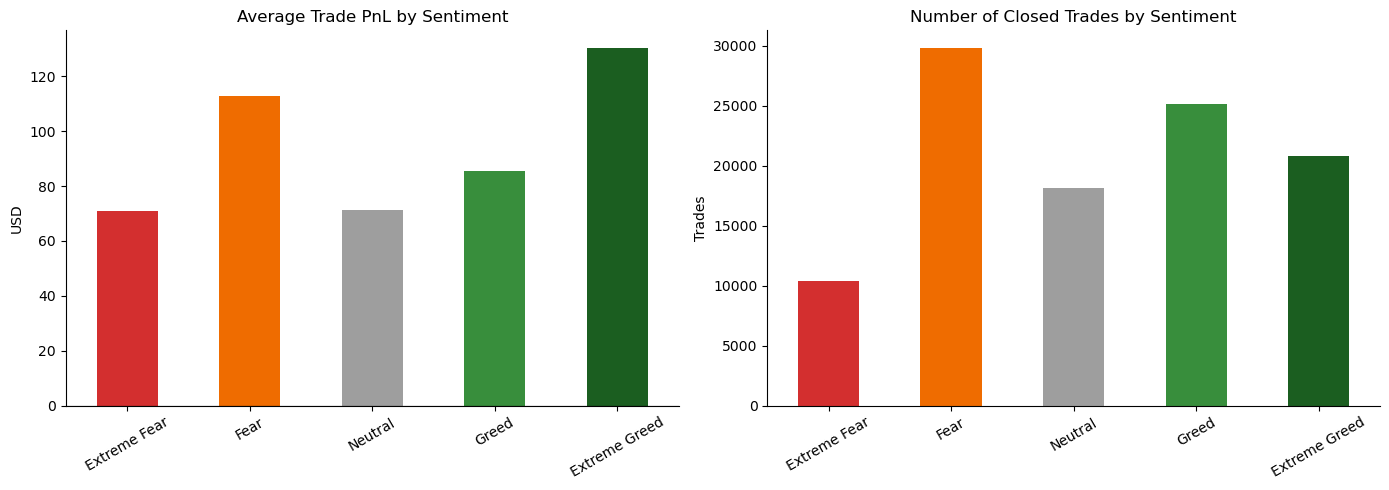

In [17]:
# Trade direction — must be created before closed subset
long_dirs  = ['Open Long', 'Close Short', 'Long > Short', 'Buy']
short_dirs = ['Open Short', 'Close Long', 'Short > Long', 'Sell']
df['trade_direction'] = df['Direction'].apply(
    lambda x: 'Long' if x in long_dirs else ('Short' if x in short_dirs else 'Other')
)

# Only closed trades (non-zero PnL)
closed = df[df['Closed PnL'] != 0].copy()
closed['is_win'] = closed['Closed PnL'] > 0

pnl_by_sentiment = (
    closed.groupby('classification')['Closed PnL']
    .agg(['mean', 'median', 'sum', 'count'])
    .loc[SENTIMENT_ORDER]
    .rename(columns={'mean':'Mean PnL', 'median':'Median PnL',
                     'sum':'Total PnL', 'count':'Trade Count'})
)
print(pnl_by_sentiment.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = [SENTIMENT_COLORS[s] for s in SENTIMENT_ORDER]
pnl_by_sentiment['Mean PnL'].plot.bar(ax=axes[0], color=colors)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title('Average Trade PnL by Sentiment')
axes[0].set_ylabel('USD')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

pnl_by_sentiment['Trade Count'].plot.bar(ax=axes[1], color=colors)
axes[1].set_title('Number of Closed Trades by Sentiment')
axes[1].set_ylabel('Trades')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('02_pnl_by_sentiment.png', dpi=150)
plt.show()

## 3. Win Rate by Sentiment

                Win Rate %   Wins  Total Trades
classification                                 
Extreme Fear         76.22   7931         10406
Fear                 87.29  26019         29808
Neutral              82.39  14961         18159
Greed                76.89  19358         25176
Extreme Greed        89.17  18594         20853


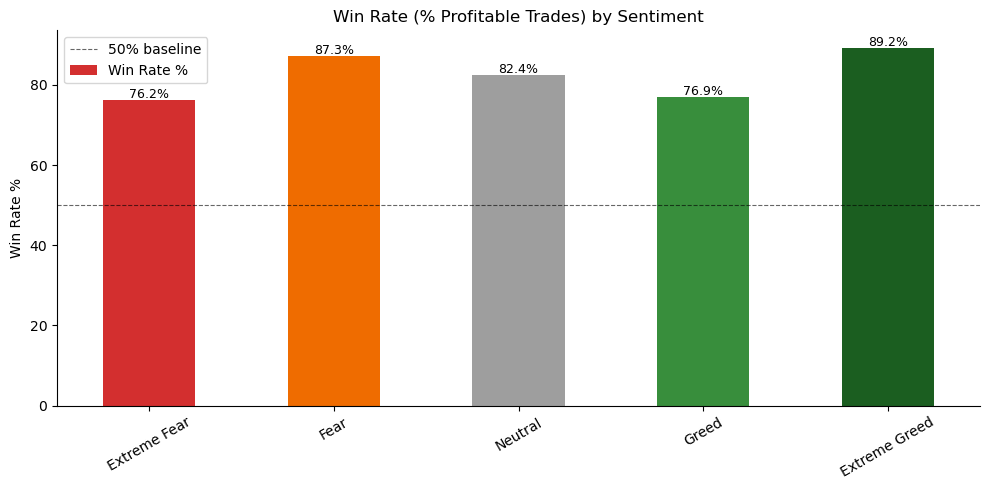

In [18]:
win_rate = (
    closed.groupby('classification')['is_win']
    .agg(['mean', 'sum', 'count'])
    .loc[SENTIMENT_ORDER]
)
win_rate['mean'] *= 100
win_rate.columns = ['Win Rate %', 'Wins', 'Total Trades']
print(win_rate.round(2))

ax = win_rate['Win Rate %'].plot.bar(
    color=[SENTIMENT_COLORS[s] for s in SENTIMENT_ORDER],
    figsize=(10, 5)
)
ax.axhline(50, color='black', linestyle='--', lw=0.8, alpha=0.6, label='50% baseline')
ax.set_title('Win Rate (% Profitable Trades) by Sentiment')
ax.set_ylabel('Win Rate %')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.legend()
for i, v in enumerate(win_rate['Win Rate %']):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('03_win_rate.png', dpi=150)
plt.show()

## 4. Long vs Short Bias Across Sentiment

trade_direction  Long  Short
classification              
Extreme Fear     51.1   48.9
Fear             49.0   51.0
Neutral          50.4   49.6
Greed            48.9   51.1
Extreme Greed    44.9   55.1


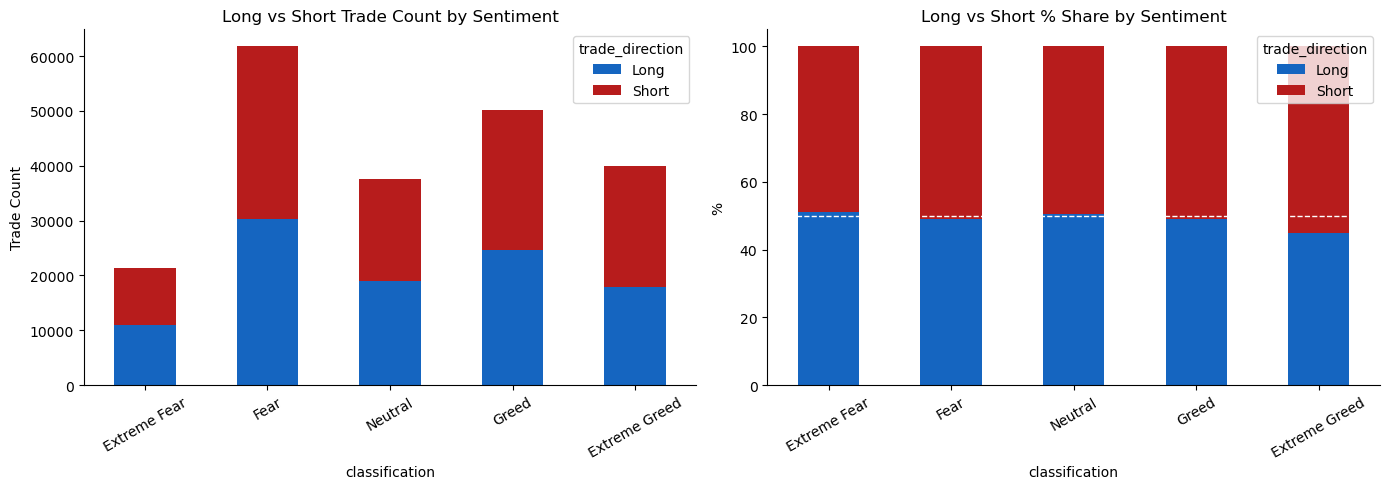

In [19]:
# Use Direction column for cleaner long/short signal
long_dirs  = ['Open Long', 'Close Short', 'Long > Short', 'Buy']
short_dirs = ['Open Short', 'Close Long', 'Short > Long', 'Sell']

df['trade_direction'] = df['Direction'].apply(
    lambda x: 'Long' if x in long_dirs else ('Short' if x in short_dirs else 'Other')
)

direction_df = df[df['trade_direction'].isin(['Long', 'Short'])]

bias = (
    direction_df.groupby(['classification', 'trade_direction'])
    .size().unstack(fill_value=0)
    .loc[SENTIMENT_ORDER]
)
bias_pct = bias.div(bias.sum(axis=1), axis=0) * 100
print(bias_pct.round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bias.plot.bar(ax=axes[0], stacked=True, color=['#1565c0','#b71c1c'])
axes[0].set_title('Long vs Short Trade Count by Sentiment')
axes[0].set_ylabel('Trade Count')
axes[0].tick_params(axis='x', rotation=30)

bias_pct.plot.bar(ax=axes[1], stacked=True, color=['#1565c0','#b71c1c'])
axes[1].set_title('Long vs Short % Share by Sentiment')
axes[1].set_ylabel('%')
axes[1].axhline(50, color='white', lw=1, ls='--')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('04_long_short_bias.png', dpi=150)
plt.show()

## 5. Long vs Short PnL Performance by Sentiment

Mean PnL — Long vs Short by Sentiment:
trade_direction    Long   Short
classification                 
Extreme Fear     123.20   48.66
Fear             207.57   70.07
Neutral           94.69   60.00
Greed             55.16  107.02
Extreme Greed     29.10  175.95


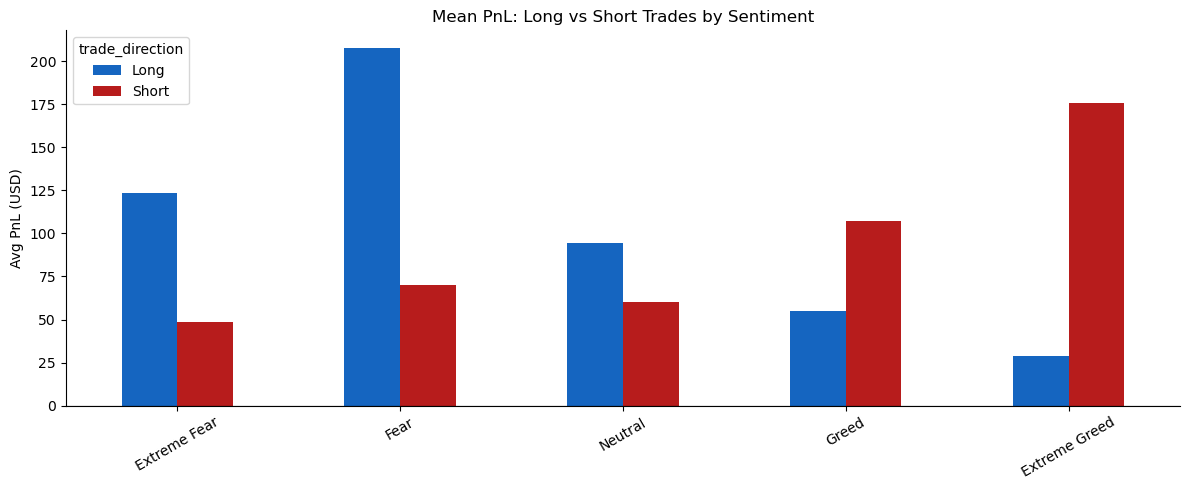

In [20]:
closed2 = closed[closed['trade_direction'].isin(['Long', 'Short'])]

ls_pnl = (
    closed2.groupby(['classification', 'trade_direction'])['Closed PnL']
    .mean().unstack()
    .loc[SENTIMENT_ORDER]
)
print('Mean PnL — Long vs Short by Sentiment:')
print(ls_pnl.round(2))

ax = ls_pnl.plot.bar(figsize=(12, 5), color=['#1565c0', '#b71c1c'])
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Mean PnL: Long vs Short Trades by Sentiment')
ax.set_ylabel('Avg PnL (USD)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('05_long_short_pnl.png', dpi=150)
plt.show()

## 6. Trade Size (USD) by Sentiment

                Mean Size USD  Median Size USD
classification                                
Extreme Fear          5349.73           766.15
Fear                  7816.11           735.96
Neutral               4782.73           547.66
Greed                 5736.88           555.00
Extreme Greed         3112.25           500.05


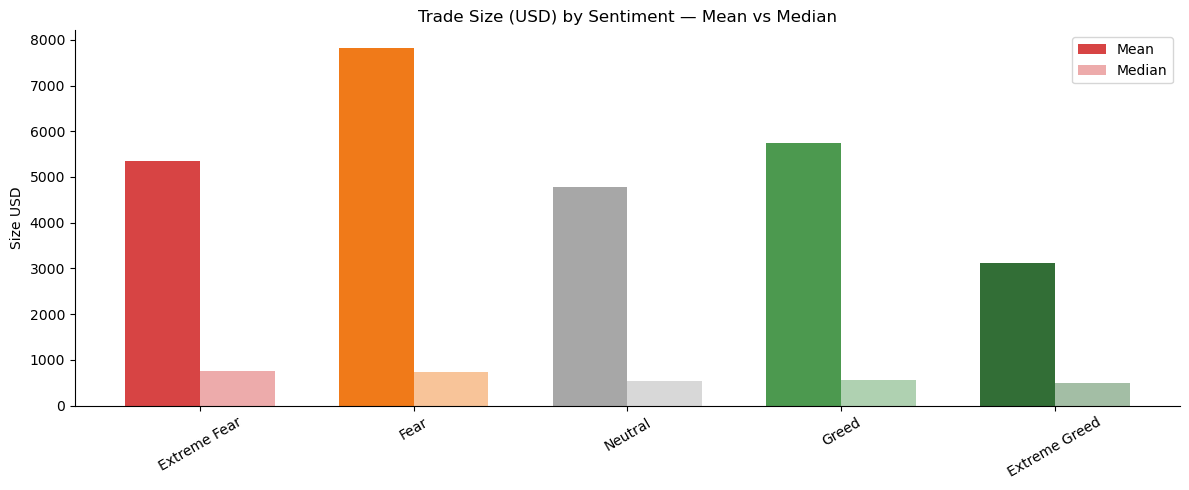

In [21]:
size_stats = (
    df.groupby('classification')['Size USD']
    .agg(['mean', 'median'])
    .loc[SENTIMENT_ORDER]
    .rename(columns={'mean': 'Mean Size USD', 'median': 'Median Size USD'})
)
print(size_stats.round(2))

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(SENTIMENT_ORDER))
w = 0.35
ax.bar([i - w/2 for i in x], size_stats['Mean Size USD'],
       width=w, label='Mean', color=[SENTIMENT_COLORS[s] for s in SENTIMENT_ORDER], alpha=0.9)
ax.bar([i + w/2 for i in x], size_stats['Median Size USD'],
       width=w, label='Median', color=[SENTIMENT_COLORS[s] for s in SENTIMENT_ORDER], alpha=0.4)
ax.set_xticks(list(x))
ax.set_xticklabels(SENTIMENT_ORDER, rotation=30)
ax.set_title('Trade Size (USD) by Sentiment — Mean vs Median')
ax.set_ylabel('Size USD')
ax.legend()
plt.tight_layout()
plt.savefig('06_trade_size.png', dpi=150)
plt.show()

## 7. PnL Distribution (Box Plot) by Sentiment

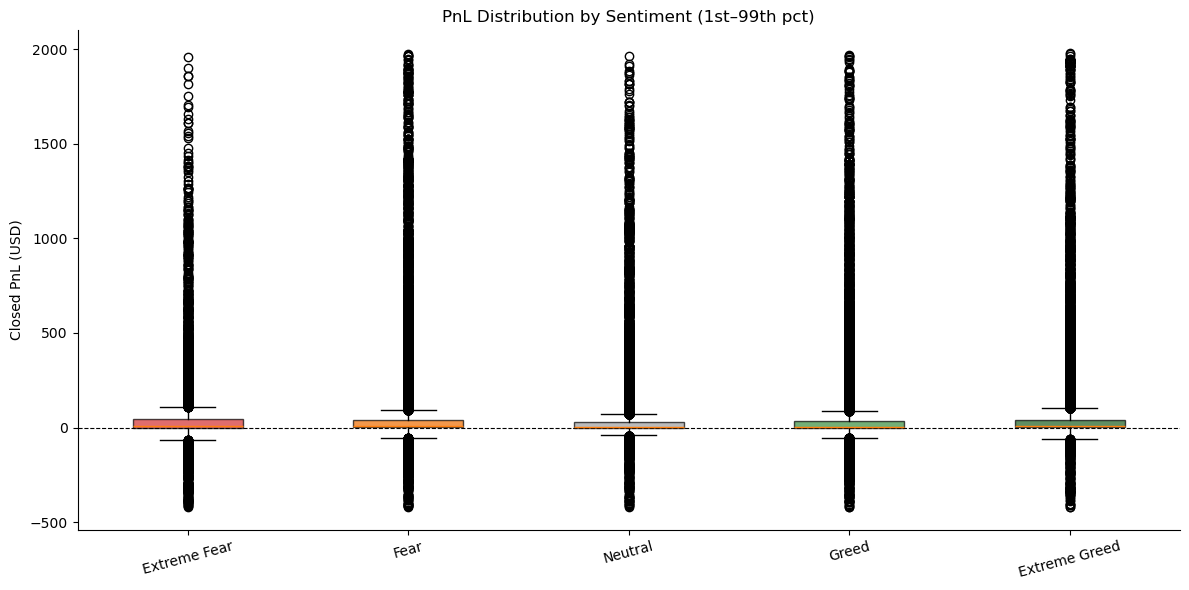

In [22]:
# Cap outliers for readability
p1, p99 = closed['Closed PnL'].quantile([0.01, 0.99])
closed_clipped = closed[closed['Closed PnL'].between(p1, p99)]

fig, ax = plt.subplots(figsize=(12, 6))
data_to_plot = [closed_clipped[closed_clipped['classification'] == s]['Closed PnL'].values
                for s in SENTIMENT_ORDER]

bp = ax.boxplot(data_to_plot, patch_artist=True, labels=SENTIMENT_ORDER, notch=False)
for patch, s in zip(bp['boxes'], SENTIMENT_ORDER):
    patch.set_facecolor(SENTIMENT_COLORS[s])
    patch.set_alpha(0.7)

ax.axhline(0, color='black', linestyle='--', lw=0.8)
ax.set_title('PnL Distribution by Sentiment (1st–99th pct)')
ax.set_ylabel('Closed PnL (USD)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('07_pnl_distribution.png', dpi=150)
plt.show()

## 8. Sentiment Transition Analysis
Does entering a new sentiment phase (e.g. Fear → Greed) create trading opportunities?

                               mean_pnl  trade_count   total_pnl
transition                                                      
Extreme Greed → Extreme Greed    107.21        17451  1870955.14
Fear → Fear                      115.96        17141  1987596.09
Greed → Greed                     86.33        13822  1193306.04
Neutral → Neutral                 60.37         9762   589307.68
Neutral → Fear                    70.18         6991   490651.80
Neutral → Greed                  -26.87         6351  -170670.23
Extreme Fear → Extreme Fear       77.41         6074   470166.53
Fear → Neutral                    95.16         5503   523683.72
Extreme Fear → Fear              122.11         4337   529572.04
Fear → Extreme Fear               62.08         4332   268943.72


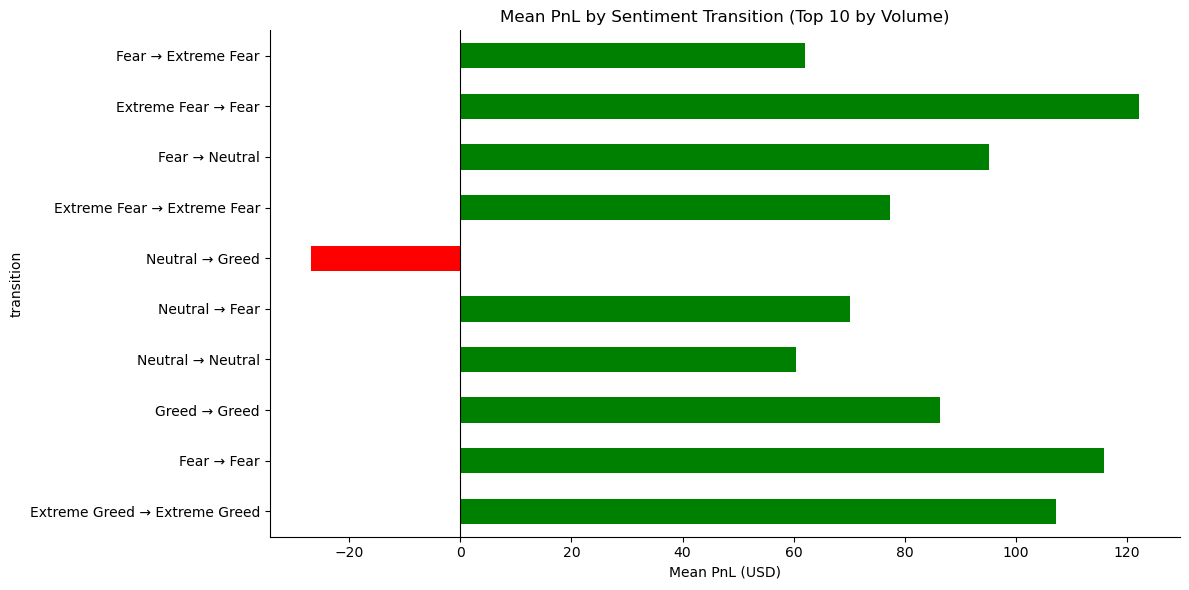

In [23]:
daily_fg_sorted = df_fg.sort_values('date').copy()
daily_fg_sorted['prev_class'] = daily_fg_sorted['classification'].shift(1)
daily_fg_sorted['transition'] = daily_fg_sorted['prev_class'] + ' → ' + daily_fg_sorted['classification']

# Merge transitions back
df_trans = pd.merge(
    closed,
    daily_fg_sorted[['date', 'transition', 'prev_class']],
    on='date', how='left'
)

# Top 10 transitions by trade volume
top_transitions = (
    df_trans.groupby('transition')
    .agg(mean_pnl=('Closed PnL', 'mean'),
         trade_count=('Closed PnL', 'count'),
         total_pnl=('Closed PnL', 'sum'))
    .sort_values('trade_count', ascending=False)
    .head(10)
)
print(top_transitions.round(2))

ax = top_transitions['mean_pnl'].plot.barh(
    figsize=(12, 6),
    color=['green' if v > 0 else 'red' for v in top_transitions['mean_pnl']]
)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Mean PnL by Sentiment Transition (Top 10 by Volume)')
ax.set_xlabel('Mean PnL (USD)')
plt.tight_layout()
plt.savefig('08_sentiment_transitions.png', dpi=150)
plt.show()

## 9. Top Trader Performance Analysis

Top 10 Traders by Total PnL:
                                             total_pnl  mean_pnl  trade_count  \
Account                                                                         
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  2143382.60    341.36         6279   
0x083384f897ee0f19899168e3b1bec365f52a9012  1600229.82    923.92         1732   
0xbaaaf6571ab7d571043ff1e313a9609a10637864   940163.81     94.04         9997   
0x513b8629fe877bb581bf244e326a047b249c4ff1   840422.56    153.31         5482   
0xbee1707d6b44d4d52bfe19e41f8a828645437aab   836080.55     37.08        22551   
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4   677747.05    303.51         2233   
0x72743ae2822edd658c0c50608fd7c5c501b2afbd   429355.57    582.57          737   
0x430f09841d65beb3f27765503d0f850b8bce7713   416541.87    695.40          599   
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4   379095.41     43.78         8660   
0x72c6a4624e1dffa724e6d00d64ceae698af892a0   360539.51    646.13          558   

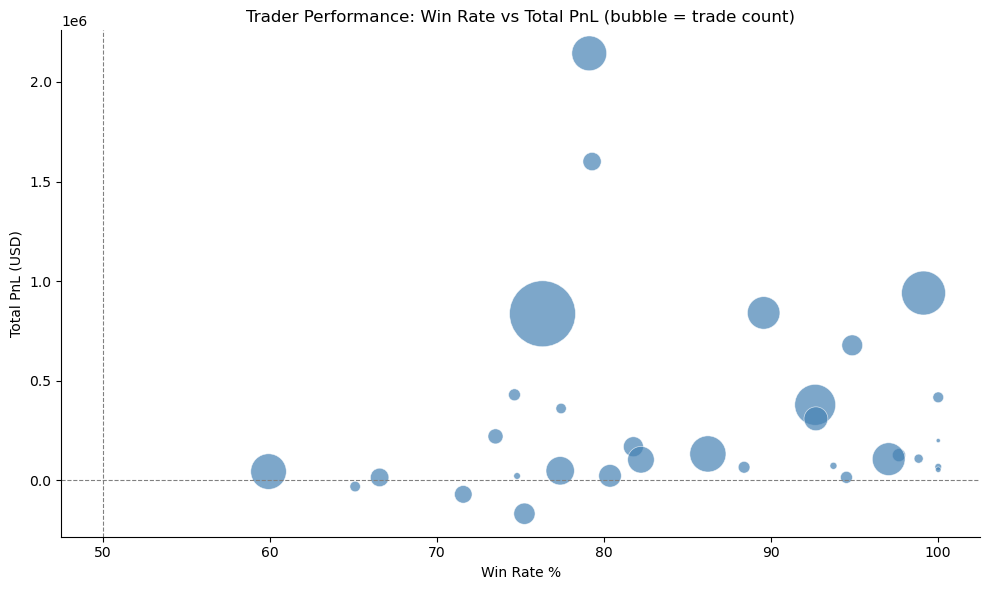

In [24]:
trader_stats = (
    closed.groupby('Account')
    .agg(
        total_pnl   =('Closed PnL', 'sum'),
        mean_pnl    =('Closed PnL', 'mean'),
        trade_count =('Closed PnL', 'count'),
        win_rate    =('is_win', 'mean')
    )
    .sort_values('total_pnl', ascending=False)
)
trader_stats['win_rate'] *= 100
print('Top 10 Traders by Total PnL:')
print(trader_stats.head(10).round(2))

# Scatter: total PnL vs win rate
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    trader_stats['win_rate'],
    trader_stats['total_pnl'],
    s=trader_stats['trade_count'] / 10,
    alpha=0.7, c='steelblue', edgecolors='white', linewidth=0.5
)
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axvline(50, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Win Rate %')
ax.set_ylabel('Total PnL (USD)')
ax.set_title('Trader Performance: Win Rate vs Total PnL (bubble = trade count)')
plt.tight_layout()
plt.savefig('09_trader_scatter.png', dpi=150)
plt.show()

## 10. Best vs Worst Traders — Behavior Under Sentiment

                Top 5 Traders  Bottom 5 Traders
classification                                 
Extreme Fear            68.84            -50.20
Fear                   129.82            102.12
Neutral                104.22             50.54
Greed                  145.78           -255.02
Extreme Greed          272.81            161.08


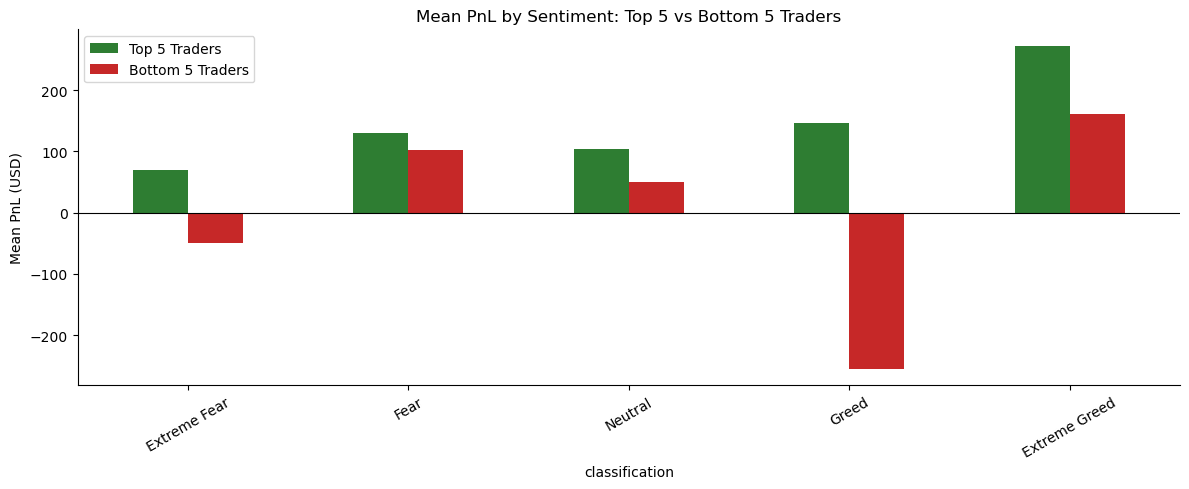

In [25]:
n = 5  # top/bottom N traders
top_traders    = trader_stats.head(n).index.tolist()
bottom_traders = trader_stats.tail(n).index.tolist()

def sentiment_profile(accounts, label):
    sub = closed[closed['Account'].isin(accounts)]
    profile = (
        sub.groupby('classification')['Closed PnL']
        .mean().reindex(SENTIMENT_ORDER)
    )
    return profile.rename(label)

profile_top    = sentiment_profile(top_traders, 'Top 5 Traders')
profile_bottom = sentiment_profile(bottom_traders, 'Bottom 5 Traders')

comparison = pd.concat([profile_top, profile_bottom], axis=1)
print(comparison.round(2))

ax = comparison.plot.bar(figsize=(12, 5), color=['#2e7d32', '#c62828'])
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Mean PnL by Sentiment: Top 5 vs Bottom 5 Traders')
ax.set_ylabel('Mean PnL (USD)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('10_top_vs_bottom.png', dpi=150)
plt.show()

## 11. Cumulative PnL Over Time (by Sentiment Phase)

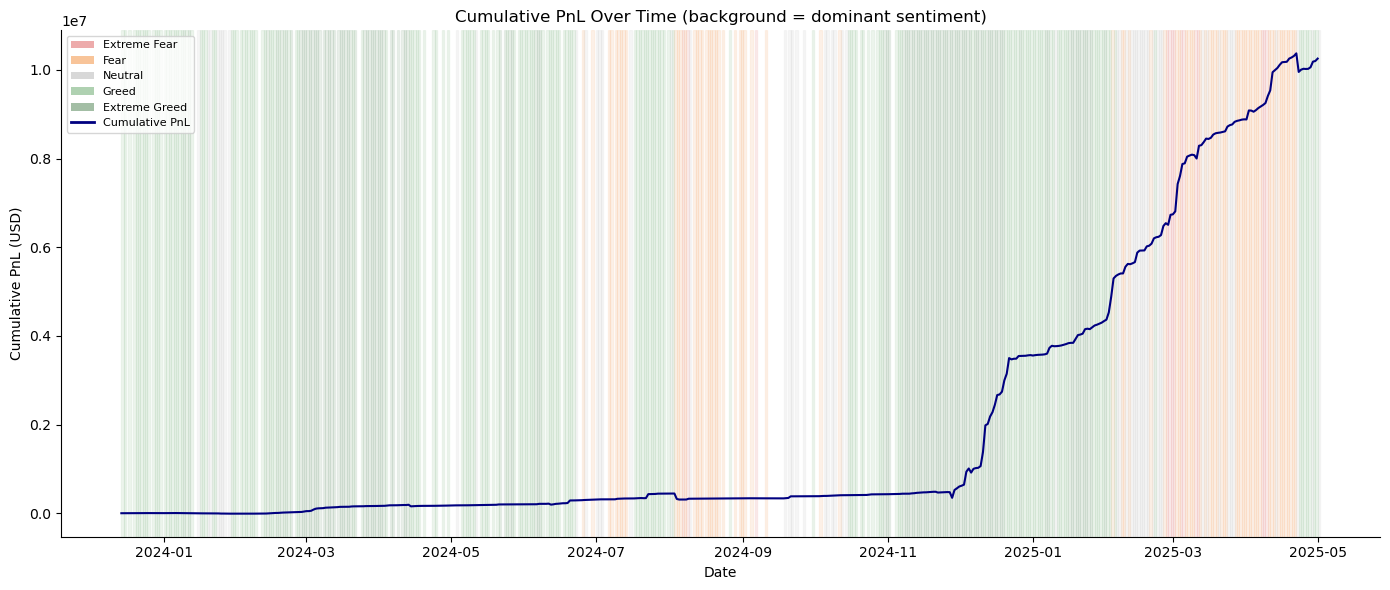

In [26]:
daily_pnl = (
    closed.groupby(['date', 'classification'])['Closed PnL']
    .sum().reset_index()
)
daily_pnl['date'] = pd.to_datetime(daily_pnl['date'])
daily_total = daily_pnl.groupby('date')['Closed PnL'].sum().sort_index()
cumulative  = daily_total.cumsum()

# Color background by dominant sentiment per day
dom_sentiment = (
    daily_pnl.groupby('date')
    .apply(lambda x: x.loc[x['Closed PnL'].abs().idxmax(), 'classification'])
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(cumulative.index, cumulative.values, color='navy', lw=1.5, label='Cumulative PnL')

for sentiment in SENTIMENT_ORDER:
    dates = dom_sentiment[dom_sentiment == sentiment].index
    for d in dates:
        ax.axvspan(d, d + pd.Timedelta(days=1),
                   alpha=0.08, color=SENTIMENT_COLORS[sentiment])

# Legend for sentiment bands
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=SENTIMENT_COLORS[s], alpha=0.4, label=s) for s in SENTIMENT_ORDER]
legend_elements.append(plt.Line2D([0], [0], color='navy', lw=2, label='Cumulative PnL'))
ax.legend(handles=legend_elements, loc='upper left', fontsize=8)

ax.set_title('Cumulative PnL Over Time (background = dominant sentiment)')
ax.set_ylabel('Cumulative PnL (USD)')
ax.set_xlabel('Date')
plt.tight_layout()
plt.savefig('11_cumulative_pnl.png', dpi=150)
plt.show()

## 12. Key Insights Summary

*(Fill these in after running the notebook — use actual numbers from your outputs)*

1. **Best sentiment to trade in:** Which classification had the highest mean/median PnL?
2. **Win rate pattern:** Did win rates consistently exceed 50% in any phase?
3. **Long/Short bias:** Do traders over-index on longs during Greed? Does it help or hurt?
4. **Trade size behaviour:** Do traders size up or down during Extreme Greed/Fear?
5. **Transition opportunity:** Which sentiment transitions produced the best mean PnL?
6. **Top traders edge:** What do profitable traders do differently during Fear phases?
7. **Cumulative PnL:** Were there sentiment phases where collective losses clustered?

In [27]:
# ── Quick summary table ────────────────────────────────────────────────────
summary = (
    closed.groupby('classification')
    .agg(
        Trades       = ('Closed PnL', 'count'),
        Mean_PnL     = ('Closed PnL', 'mean'),
        Median_PnL   = ('Closed PnL', 'median'),
        Total_PnL    = ('Closed PnL', 'sum'),
        Win_Rate_pct = ('is_win', lambda x: round(x.mean()*100, 1))
    )
    .loc[SENTIMENT_ORDER]
    .round(2)
)
print('\n=== FINAL SUMMARY TABLE ===')
print(summary.to_string())


=== FINAL SUMMARY TABLE ===
                Trades  Mean_PnL  Median_PnL   Total_PnL  Win_Rate_pct
classification                                                        
Extreme Fear     10406     71.03        6.39   739110.25          76.2
Fear             29808    112.63        6.35  3357155.44          87.3
Neutral          18159     71.20        4.58  1292920.68          82.4
Greed            25176     85.40        4.93  2150129.27          76.9
Extreme Greed    20853    130.21        8.53  2715171.31          89.2
